##GIẢI THUẬT 2: SUPPORT VECTOR MACHINE (SVM)

###Bài thực hành 1: Xây dựng mô hình từ giải thuật SVM trên dữ liệu bệnh tiểu đường.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv("/content/drive/MyDrive/Data_Analysis/DA06/diabetes_prediction_dataset.csv")

In [12]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


###Khám phá và kiểm tra tổng quan dữ liệu ban đầu :
Đoạn mã trên thực hiện việc nạp và kiểm tra dữ liệu ban đầu của bộ dữ liệu dự đoán bệnh tiểu đường (diabetes_prediction_dataset.csv). Bộ dữ liệu gồm 100.000 mẫu và 9 cột đặc trưng, bao gồm các thông tin như giới tính, tuổi, huyết áp, bệnh tim, tiền sử hút thuốc, chỉ số BMI, mức HbA1c, lượng đường trong máu và nhãn đầu ra “diabetes” (0 hoặc 1). Hàm df.info() cho thấy dữ liệu không có giá trị thiếu (Non-Null đầy đủ) và các kiểu dữ liệu phù hợp cho cả dạng số và dạng phân loại. Bước này giúp xác nhận rằng bộ dữ liệu đã được nạp thành công và sẵn sàng cho các bước tiền xử lý và xây dựng mô hình học máy tiếp theo.

In [14]:
print(df.duplicated())
print(df.duplicated().sum())

0        False
1        False
2        False
3        False
4        False
         ...  
99995     True
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool
3854


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [18]:
df.describe(include='object')

,gender,smoking_history
count,96146,96146
unique,3,6
top,Female,never
freq,56161,34398


In [19]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


Nhận xét tổng quan :

- Bảng thống kê mô tả cho thấy bộ dữ liệu gồm 96.146 bản ghi hợp lệ, không có giá trị thiếu ở các cột số.
- Tuổi trung bình của người tham gia là khoảng 41,8 tuổi, với độ lệch chuẩn khá lớn (22,46), cho thấy độ phân tán tuổi rộng.
- Tỷ lệ người bị tăng huyết áp (7,7%) và bệnh tim (4%) khá thấp so với tổng thể.
- Chỉ số BMI trung bình khoảng 27,3, phản ánh mức cân nặng hơi cao so với tiêu chuẩn.
- Mức HbA1c trung bình là 5,53 và đường huyết trung bình khoảng 138 mg/dL, cho thấy phần lớn người trong mẫu chưa bị tiểu đường.
- Cuối cùng, biến mục tiêu “diabetes” có giá trị trung bình 0,088, nghĩa là chỉ khoảng 8,8% người trong tập dữ liệu mắc bệnh tiểu đường — cho thấy dữ liệu bị mất cân bằng lớp (class imbalance) giữa người mắc và không mắc bệnh.

In [20]:
numeric_col=[]
non_numeric_col=[]
for column in df.columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        if(df[column].nunique()<5):
            non_numeric_col.append(column)
        else:
            numeric_col.append(column)
    else:
        non_numeric_col.append(column)

In [21]:
print(numeric_col)
print(non_numeric_col)

['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
['gender', 'hypertension', 'heart_disease', 'smoking_history', 'diabetes']


In [22]:
def univariate_analysis_numeric(col):
    fig, ax = plt.subplots(1, 2, figsize=(12,10))
    sns.histplot(x=df[col], kde=True, bins=20, color='skyblue',ax=ax[0])
    ax[0].set_title(f'Histogram of {col}.')

    sns.boxplot(x=df[col],ax=ax[1])
    ax[1].set_title(f'Boxplot diagram of {col}     ')

 Univariate analysis for age column:
 Univariate analysis for bmi column:
 Univariate analysis for HbA1c_level column:
 Univariate analysis for blood_glucose_level column:


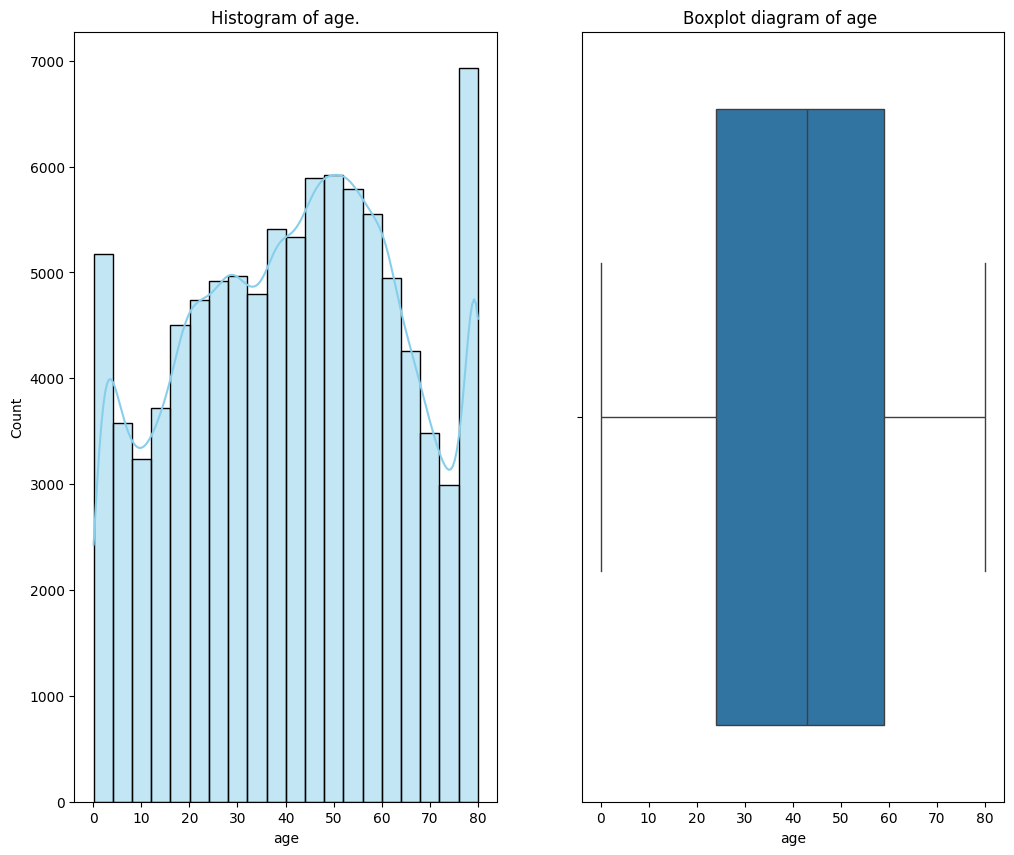

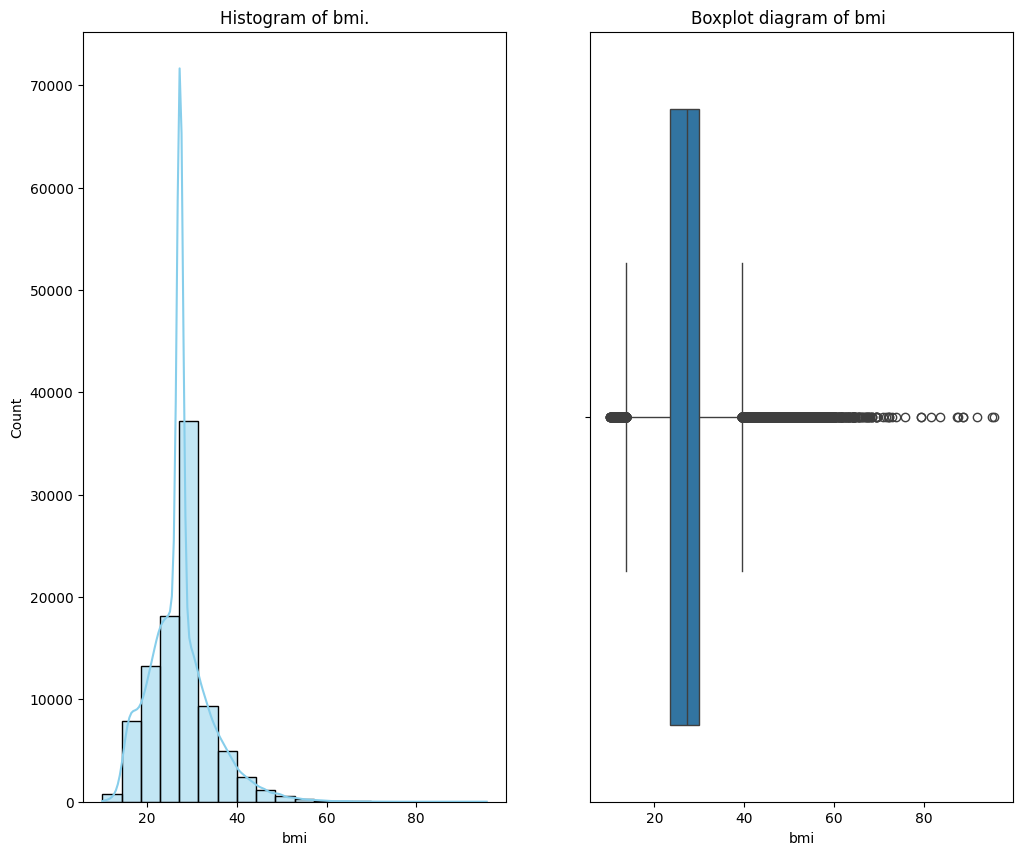

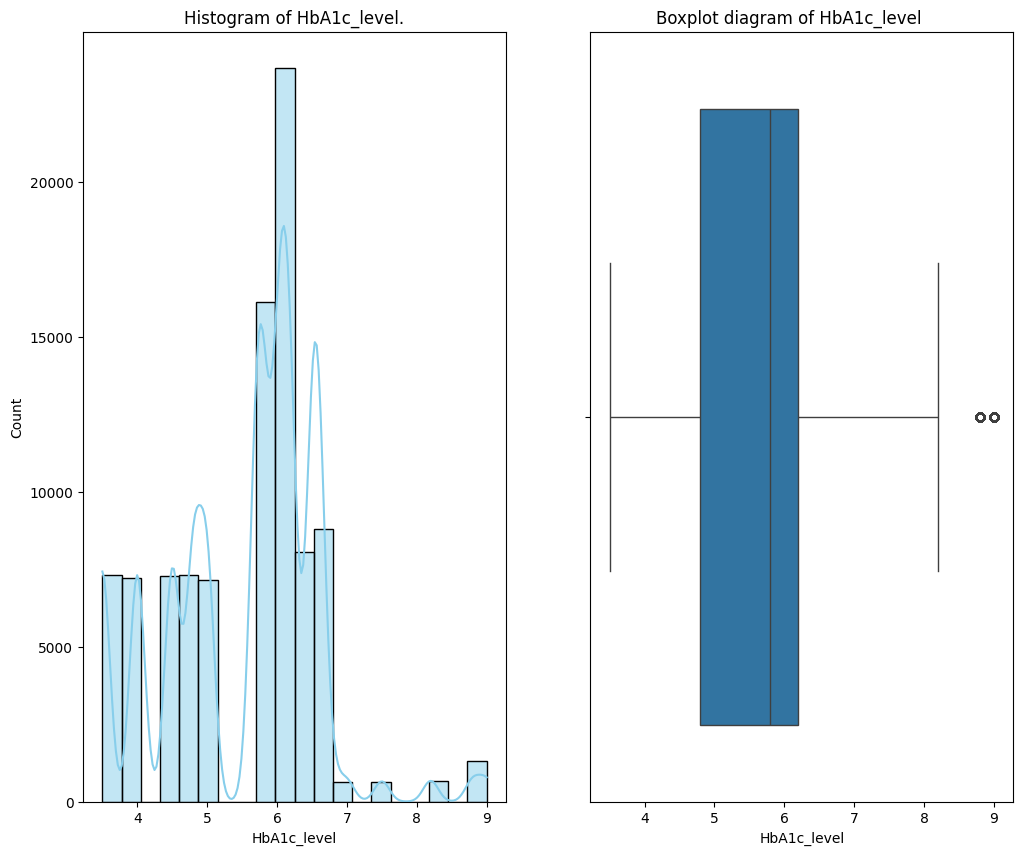

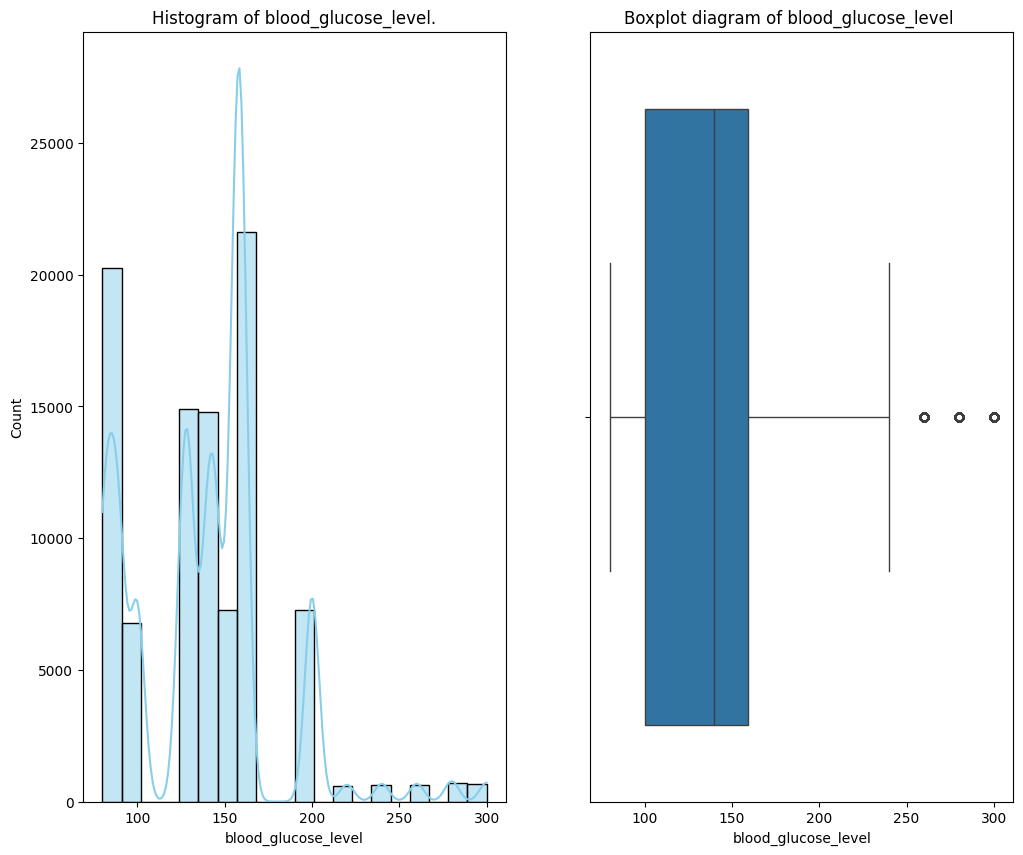

In [23]:
for col in numeric_col:
    print(f' Univariate analysis for {col} column:')
    univariate_analysis_numeric(col)

In [24]:
def univariate_analysis_cat(col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Countplot
    sns.countplot(x=df[col],data=df ,palette='viridis', ax=ax[0])
    ax[0].set_title(f'Countplot for {col}')

    # Pie plot
    data_counts = df[col].value_counts()
    ax[1].pie(data_counts, labels=data_counts.index, autopct='%1.3f%%', startangle=90, colors=sns.color_palette('pastel'))
    ax[1].set_title(f'Pie plot for {col}')

    plt.show()

 Univariate analysis for gender column:


/tmp/ipython-input-3600597884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],data=df ,palette='viridis', ax=ax[0])


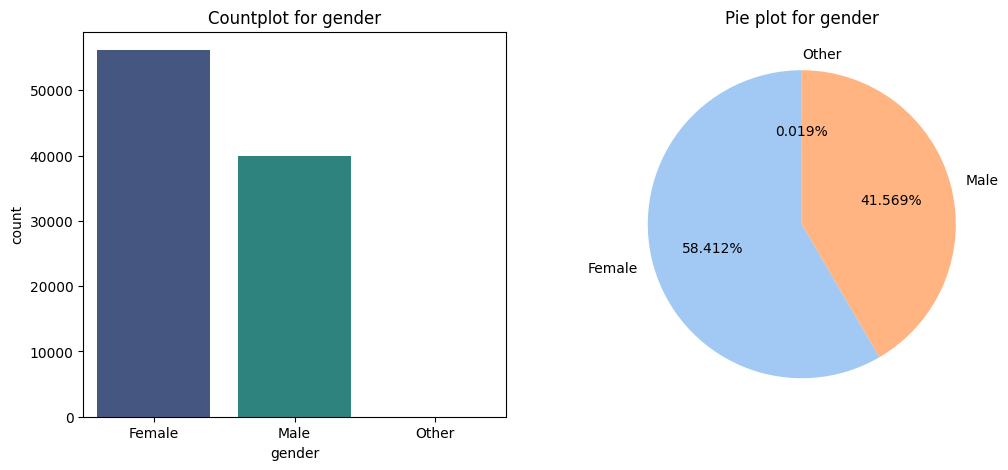

 Univariate analysis for hypertension column:


/tmp/ipython-input-3600597884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],data=df ,palette='viridis', ax=ax[0])


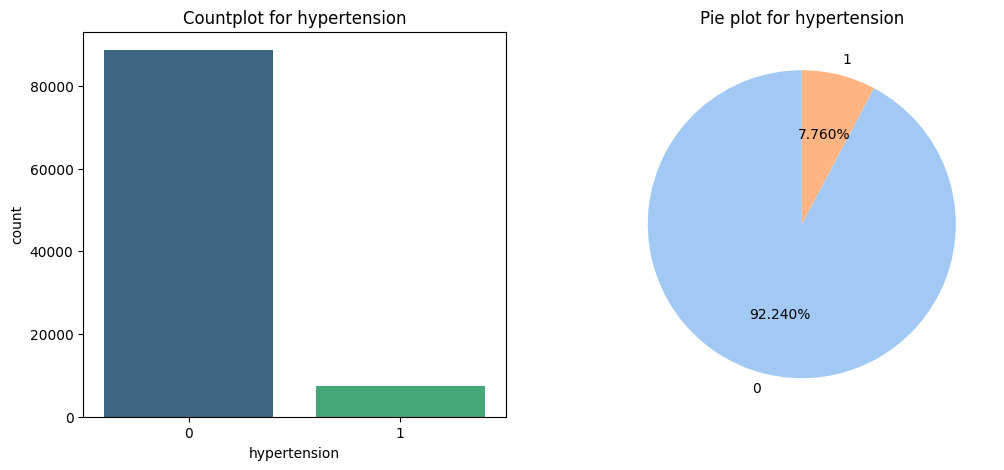

 Univariate analysis for heart_disease column:


/tmp/ipython-input-3600597884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],data=df ,palette='viridis', ax=ax[0])


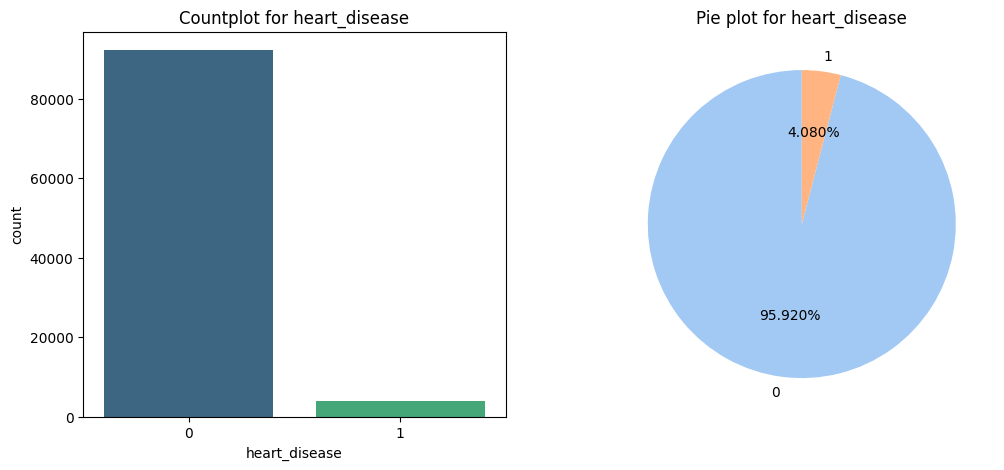

 Univariate analysis for smoking_history column:


/tmp/ipython-input-3600597884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],data=df ,palette='viridis', ax=ax[0])


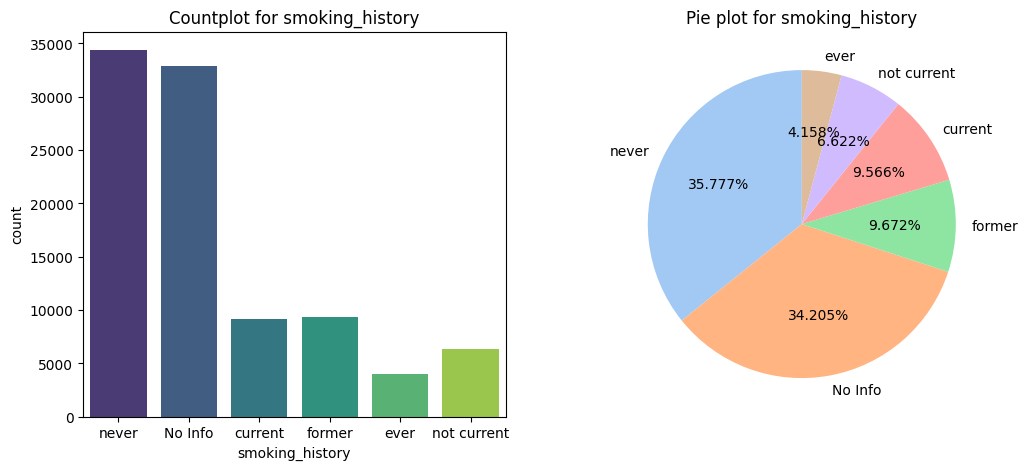

 Univariate analysis for diabetes column:


/tmp/ipython-input-3600597884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],data=df ,palette='viridis', ax=ax[0])


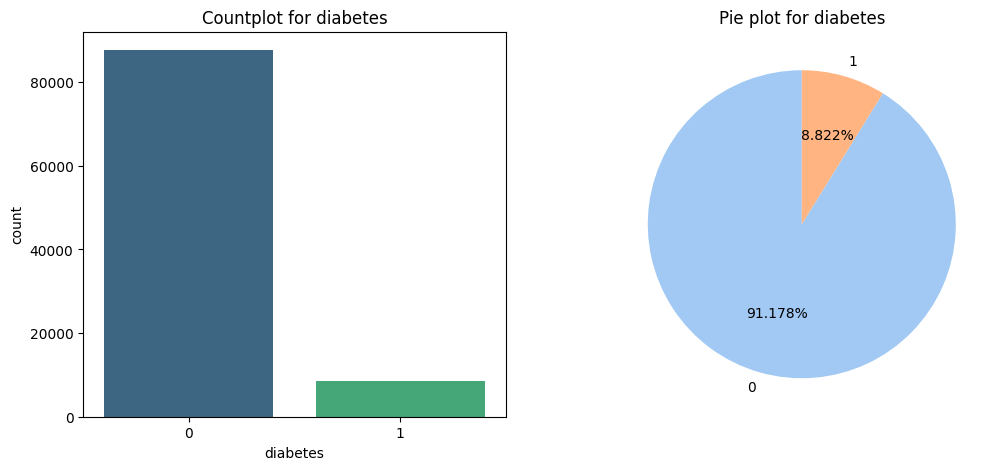

In [25]:
for col in non_numeric_col:
    print(f' Univariate analysis for {col} column:')
    univariate_analysis_cat(col)

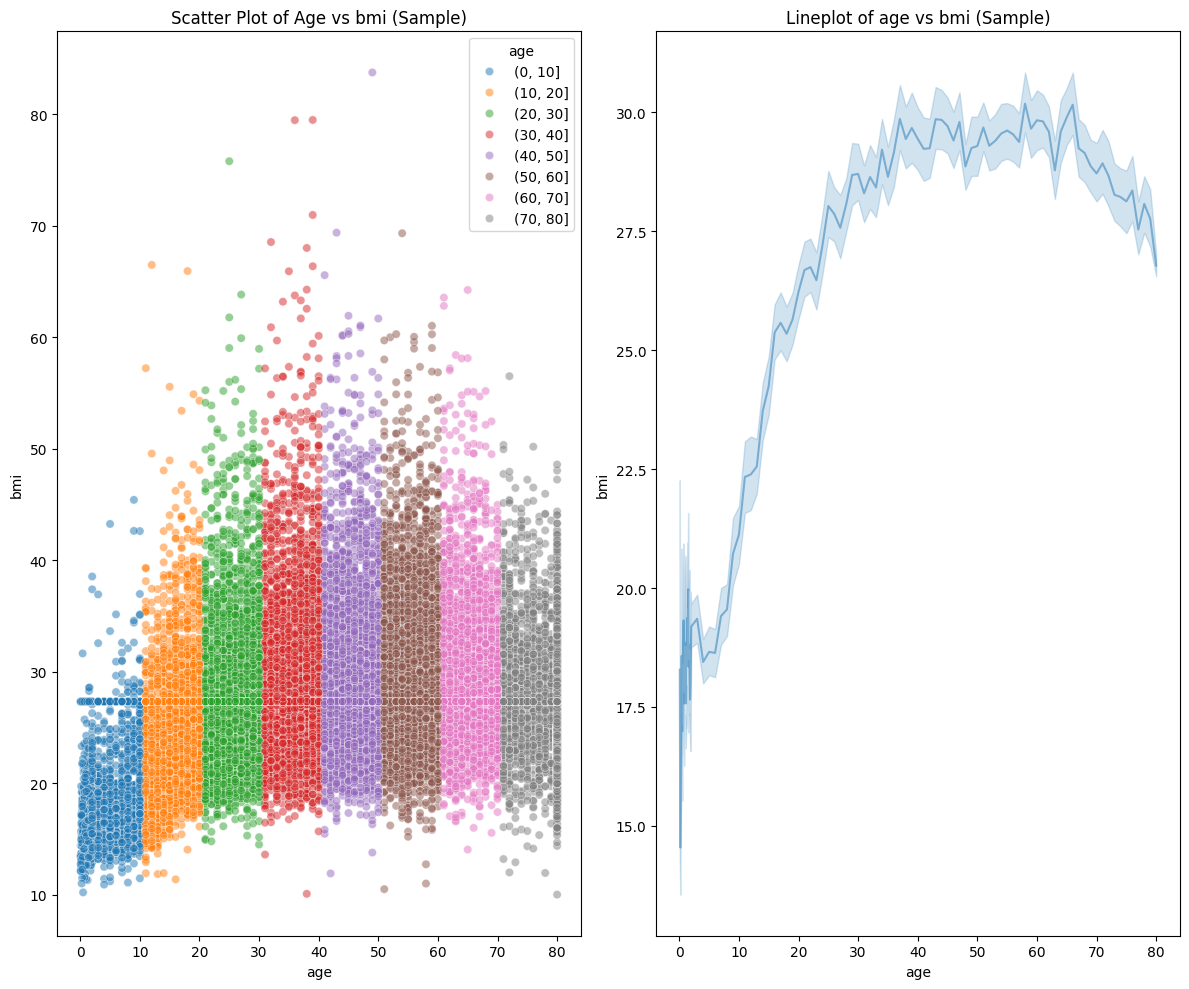

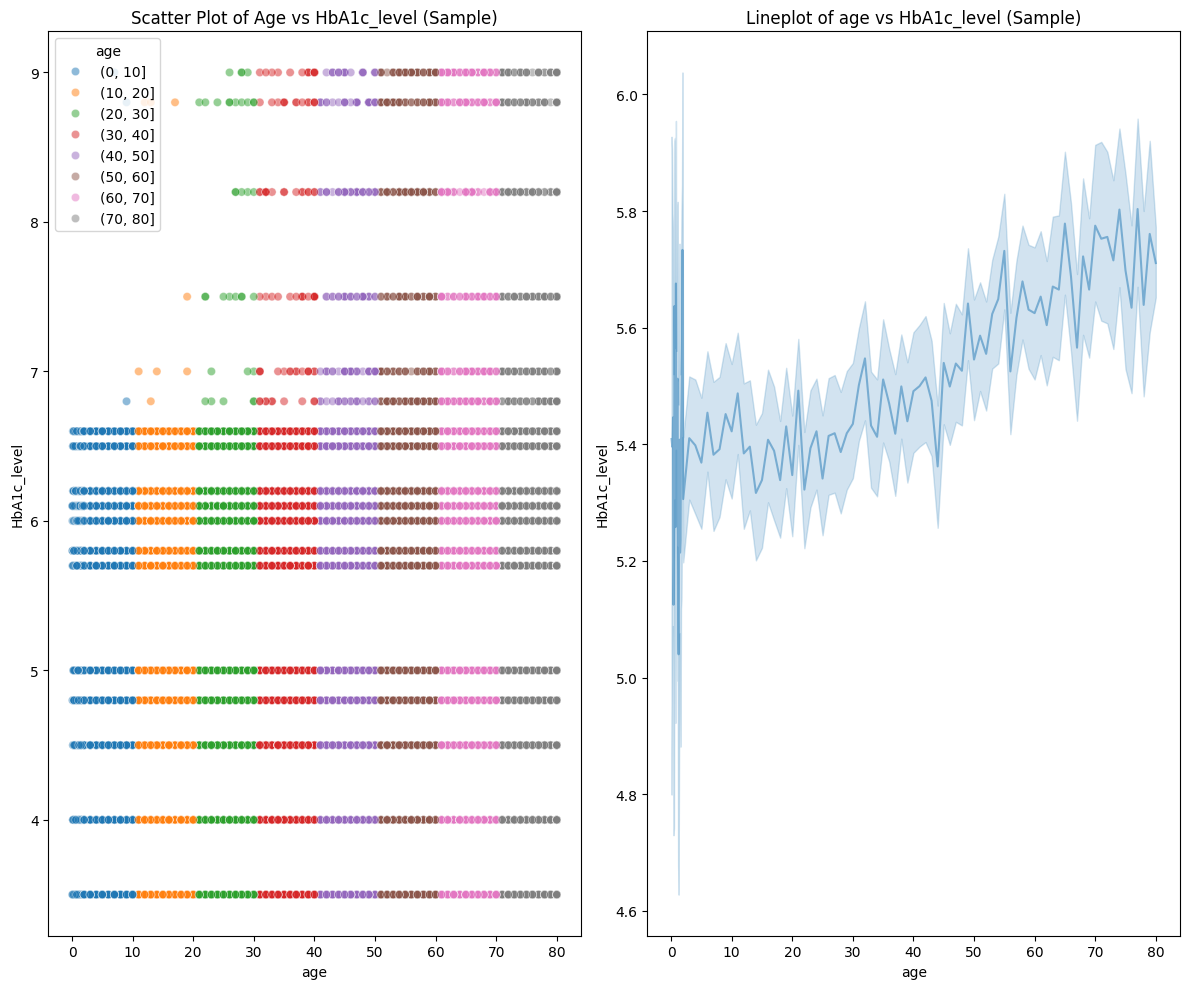

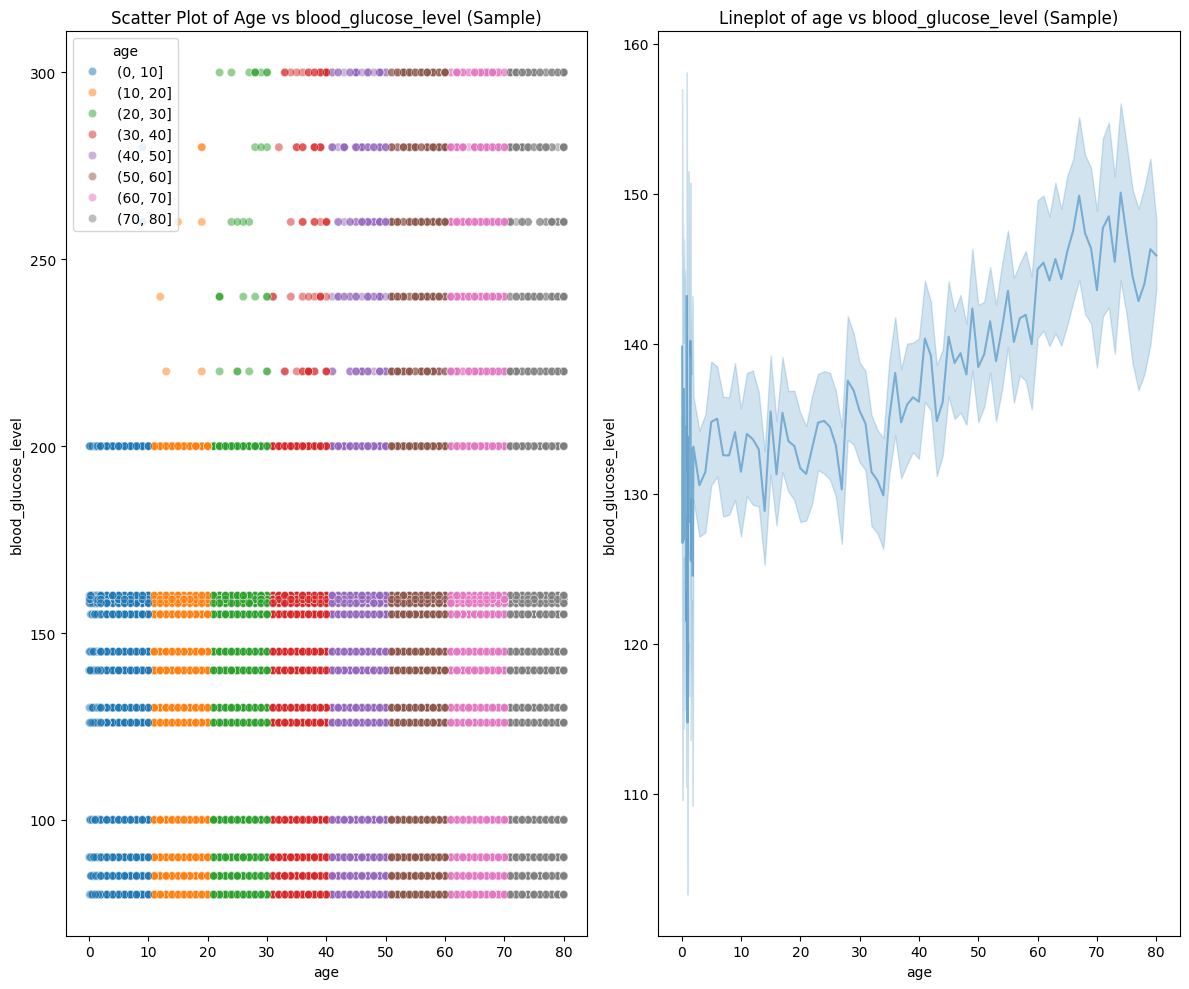

In [26]:
sample_size = 30000
sample_df = df.sample(n=sample_size, random_state=42)
age_group = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80])

for col in numeric_col[1:]:
    fig, ax = plt.subplots(1, 2, figsize=(12, 10))
    sns.scatterplot(x='age', y=df[col], data=sample_df,hue=age_group, alpha=0.5,ax=ax[0])
    ax[0].set_title(f'Scatter Plot of Age vs {col} (Sample)')

    sns.lineplot(x='age',y=df[col],data=sample_df,alpha=0.5,ax=ax[1])
    ax[1].set_title(f'Lineplot of age vs {col} (Sample)')
    plt.tight_layout()
    plt.show()

In [27]:
print(sample_df['age'].mean())
print(df['age'].mean())

41.85690399999999
41.79432571297817


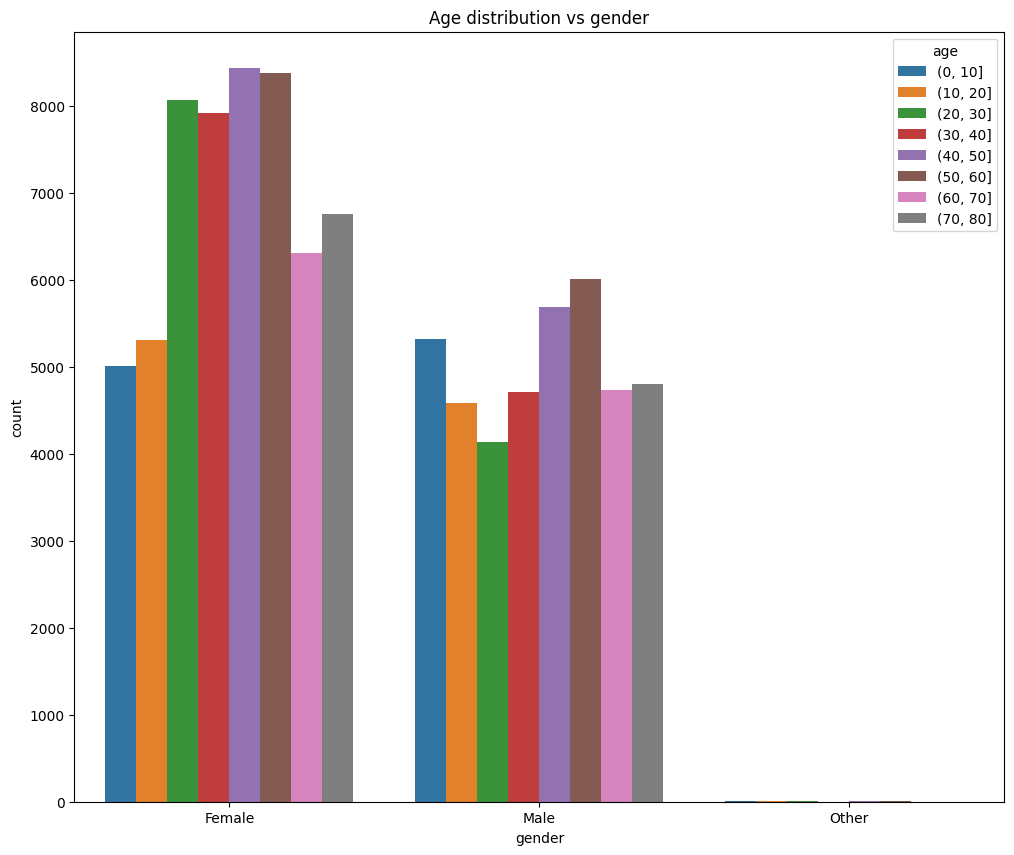

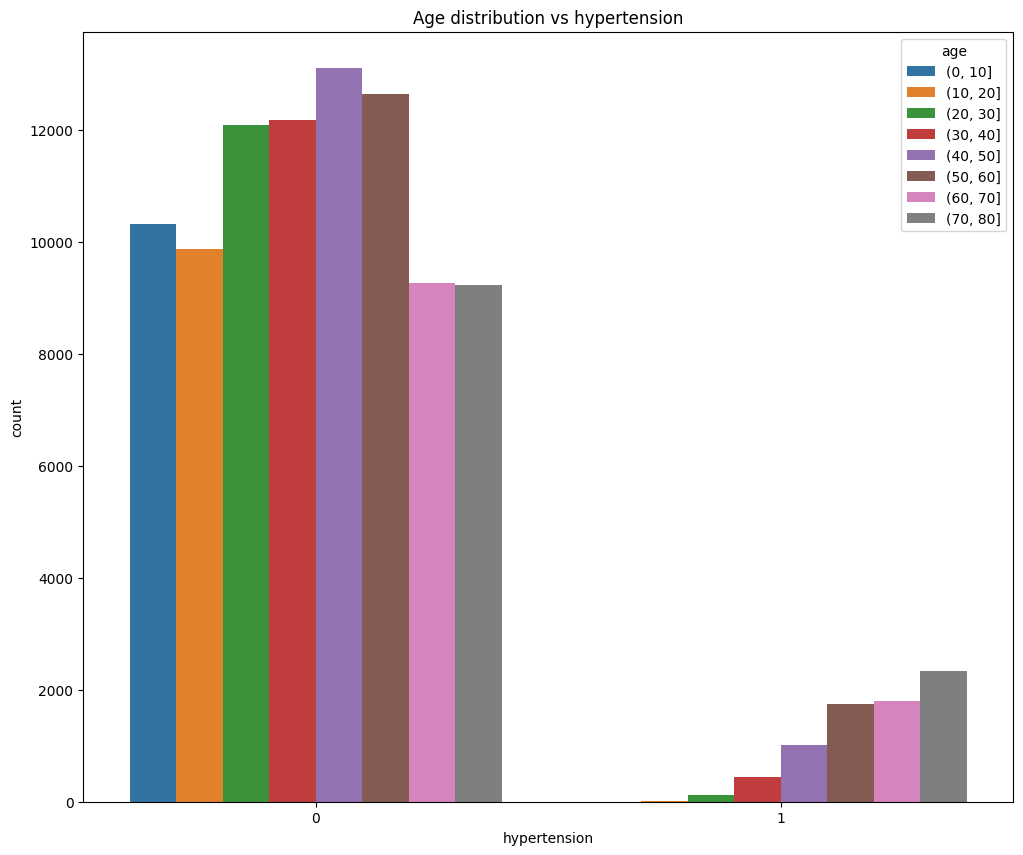

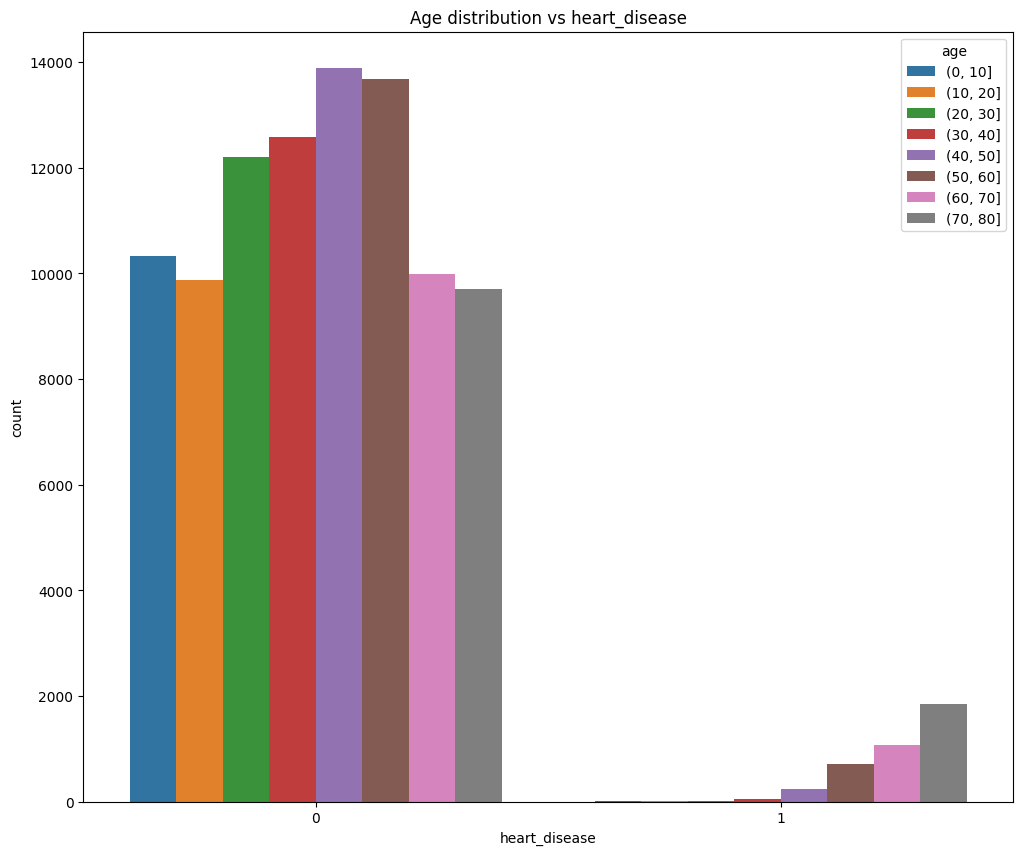

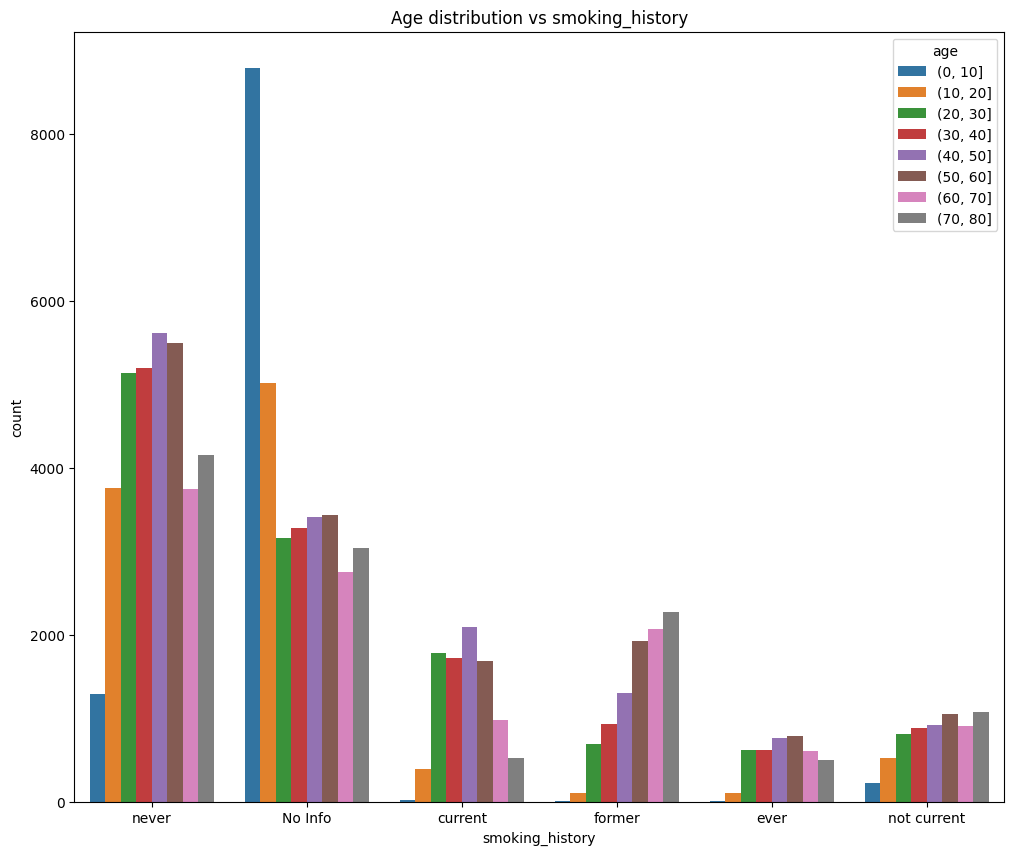

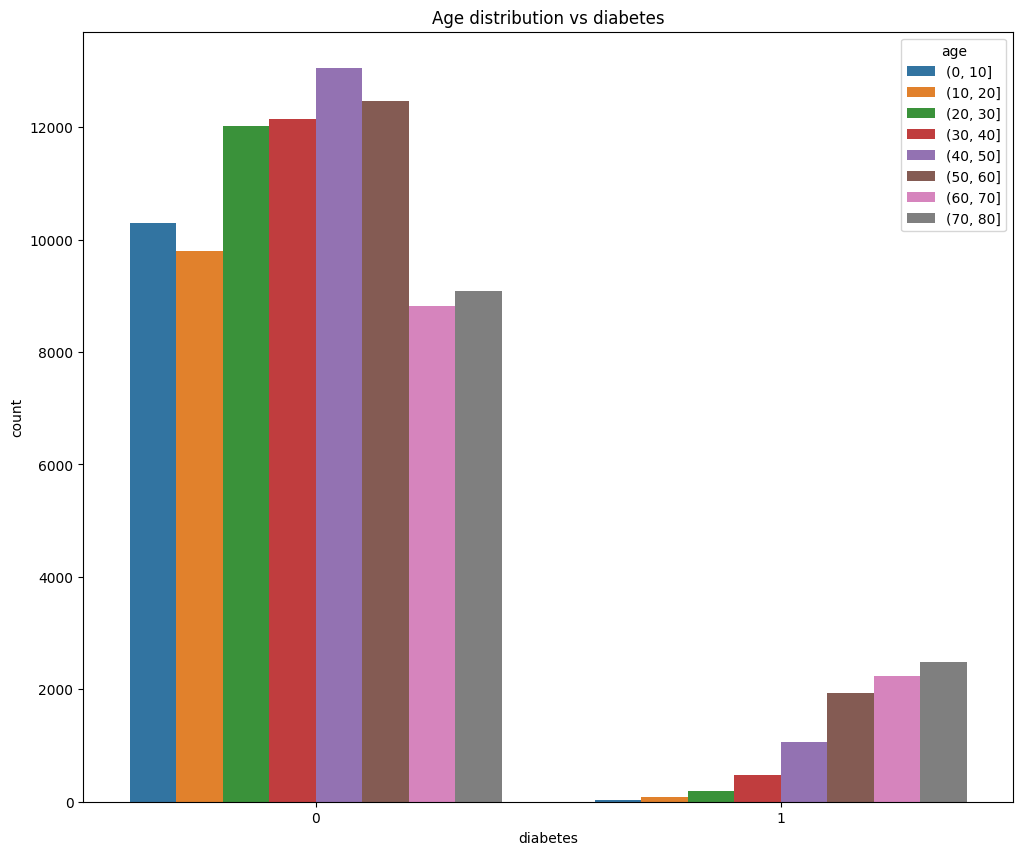

In [28]:
age_group = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80])
for i in non_numeric_col:
    plt.figure(figsize=(12,10))
    sns.countplot(x=df[i],data=df,hue=age_group)
    plt.title(f'Age distribution vs {i}')
    plt.show()


In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in non_numeric_col:
    sample_df[col]=le.fit_transform(sample_df[col])
sample_df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
2547,0,5.0,0,0,0,15.14,4.5,90,0
34774,1,19.0,0,0,4,22.74,6.6,85,0
71084,0,52.0,0,0,4,24.27,7.5,220,1
50584,1,55.0,0,0,0,27.32,5.7,85,0
80788,0,22.0,0,0,4,28.78,4.5,200,0
...,...,...,...,...,...,...,...,...,...
54431,0,26.0,0,0,3,28.27,6.2,100,0
55182,0,57.0,0,0,4,22.12,5.0,100,0
92776,1,74.0,0,1,2,29.83,4.8,160,0
76035,0,11.0,0,0,0,27.32,6.2,90,0


In [30]:
x = sample_df.drop('diabetes', axis=1)
y = sample_df['diabetes']


In [31]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)
model_svm = SVC(kernel = 'linear', random_state = 0)
model_svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

###Mã hóa dữ liệu & huấn luyện mô hình SVM (baseline)

- Đoạn mã trên mã hóa các biến phân loại trong sample_df (như gender, smoking_history) bằng LabelEncoder để chuyển sang giá trị số, tạo ra bảng 30.000 hàng × 9 cột sẵn sàng cho mô hình;
- sau đó tách đặc trưng X (mọi cột trừ diabetes) và nhãn y (diabetes), thực hiện train_test_split với test_size=0.3.
- Cuối cùng, một mô hình SVM – SVC(kernel='linear', random_state=0) được khởi tạo và fit trên tập huấn luyện để làm mốc baseline.

Lưu ý: LabelEncoder coi giá trị danh mục là thứ tự, vì vậy cho mô hình tuyến tính như SVM có thể cân nhắc OneHotEncoder và chuẩn hóa thang đo (StandardScaler) để cải thiện hiệu suất; các tham số như C, class_weight và loại kernel cũng có thể tinh chỉnh ở bước tiếp theo.

In [32]:
y_pred = model_svm.predict(X_test)

In [33]:
accuracy_svm = accuracy_score(y_test, y_pred)
print(accuracy_svm)

0.9564444444444444


In [34]:
classification_rep_svm = classification_report(y_test, y_pred)
print(classification_rep_svm)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8185
           1       0.93      0.56      0.70       815

    accuracy                           0.96      9000
   macro avg       0.94      0.78      0.84      9000
weighted avg       0.96      0.96      0.95      9000



###Đánh giá hiệu suất mô hình SVM

- Kết quả trên cho thấy mô hình SVM tuyến tính đạt độ chính xác tổng thể (accuracy) 95.6%, thể hiện khả năng phân loại rất tốt trên tập kiểm thử.
Với lớp 0 (không mắc tiểu đường), các chỉ số đều cao: precision 0.96, recall 1.00, F1-score 0.98, chứng tỏ mô hình hầu như dự đoán đúng toàn bộ các trường hợp âm tính.
- Ngược lại, lớp 1 (mắc tiểu đường) có precision 0.93 nhưng recall chỉ 0.56, cho thấy mô hình bỏ sót khá nhiều ca dương tính thật (false negatives) – một vấn đề phổ biến khi dữ liệu bị mất cân bằng.
- Giá trị macro avg F1 = 0.84 phản ánh sự chênh lệch giữa hai lớp, trong khi weighted avg F1 = 0.95 vẫn cao nhờ tỷ lệ lớp 0 chiếm ưu thế.

Tổng kết: Mô hình hoạt động tốt với độ chính xác cao, nhưng cần cải thiện khả năng phát hiện bệnh (class 1), có thể bằng cách dùng kỹ thuật cân bằng dữ liệu (SMOTE) hoặc điều chỉnh trọng số lớp (class_weight='balanced') trong SVM để đạt hiệu quả toàn diện hơn.

#Kết thúc